## Experiments with the Heston Tree model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from black_scholes.bs import black_scholes
from heston.closed import heston_call_price
from heston.tree import HestonTree

In [2]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

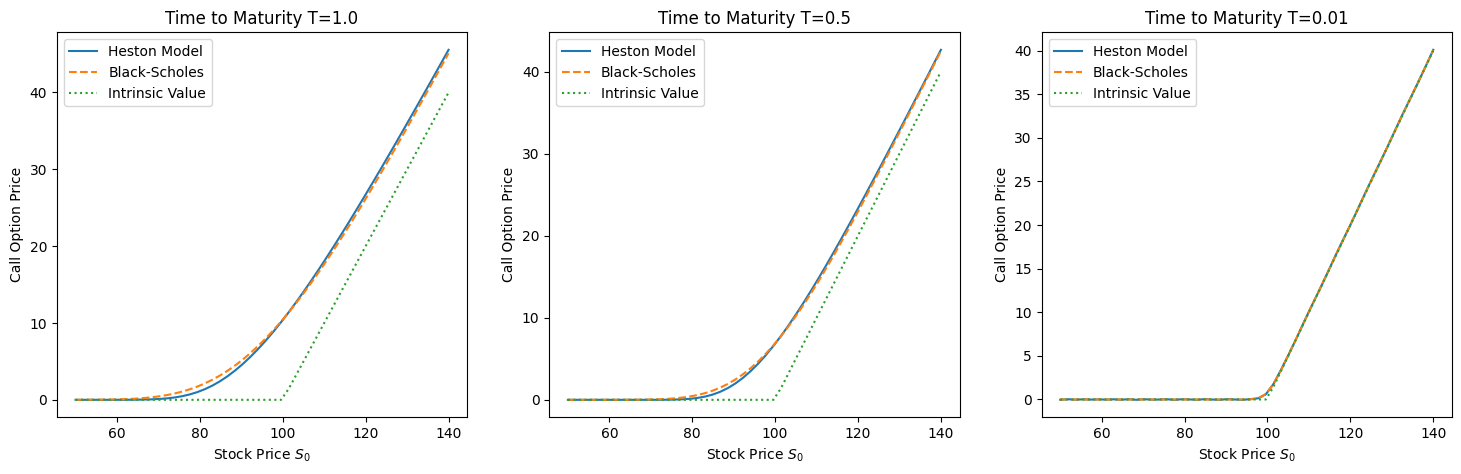

In [3]:
S = np.linspace(50, 140, 50)
intrinsic_values = np.maximum(S - K, 0)

Ts = [1.0, 0.5, 0.01]

plt.figure(figsize=(18, 5))
for i, T_ in enumerate(Ts):
    prices = [heston_call_price(S0, K, T_, r, kappa, theta, sigma, rho, v0) for S0 in S]
    bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T_, 'call') for S0 in S]
    plt.subplot(1, 3, i+1)
    plt.plot(S, prices, label='Heston Model')
    plt.plot(S, bs_prices, label='Black-Scholes', linestyle='--')
    plt.plot(S, intrinsic_values, label='Intrinsic Value', linestyle=':')
    plt.title(f'Time to Maturity T={T_}')
    plt.xlabel('Stock Price $S_0$')
    plt.ylabel('Call Option Price')
    plt.legend()
plt.show()

## Closed form vs Tree

In [4]:
n = 100
mz = 200
mv = 100
V0_min = 0.01
V0_max = 0.1
S0_min = 80
S0_max = 120

heston_tree = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

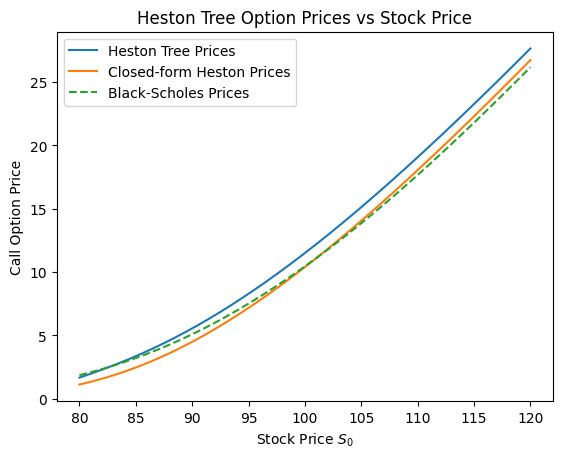

In [5]:
v0 = 0.04  # Fix initial variance
S = np.linspace(80, 120, 200)
k = 0
prices = [heston_tree.price(v0, S0, k) for S0 in S]
closed_prices = [heston_call_price(S0, K, T, r, kappa, theta, sigma, rho, v0) for S0 in S]
bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
plt.plot(S, prices, label='Heston Tree Prices')
plt.plot(S, closed_prices, label='Closed-form Heston Prices')
plt.plot(S, bs_prices, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Stock Price')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()

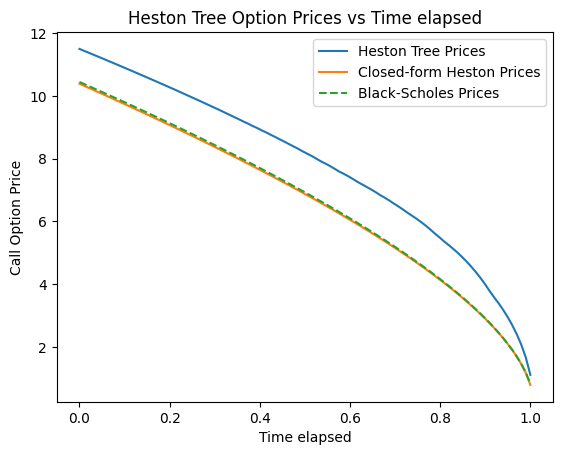

In [6]:
# Term structure
v0 = 0.04
S0 = 100.0

prices = [heston_tree.price(v0, S0, k) for k in range(n)]
prices_closed = [heston_call_price(S0, K, T - k*(T/n), r, kappa, theta, sigma, rho, v0) for k in range(n)]
prices_bs = [black_scholes(S0, K, r, np.sqrt(v0), T - k*(T/n), 'call') for k in range(n)]
plt.plot(np.linspace(0, T, n), prices, label='Heston Tree Prices')
plt.plot(np.linspace(0, T, n), prices_closed, label='Closed-form Heston Prices')
plt.plot(np.linspace(0, T, n), prices_bs, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Time elapsed')
plt.xlabel('Time elapsed')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()

## Black Scholes case

In [7]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

In [8]:
n = 100
mz = 100
mv = 100
V0_min = 0.01
V0_max = 0.1
S0_min = 80
S0_max = 120

heston_tree_bs = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree_bs.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

In [9]:
n = 100
mz = 200
mv = 100

heston_tree_bs_finer = HestonTree(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree_bs_finer.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max)

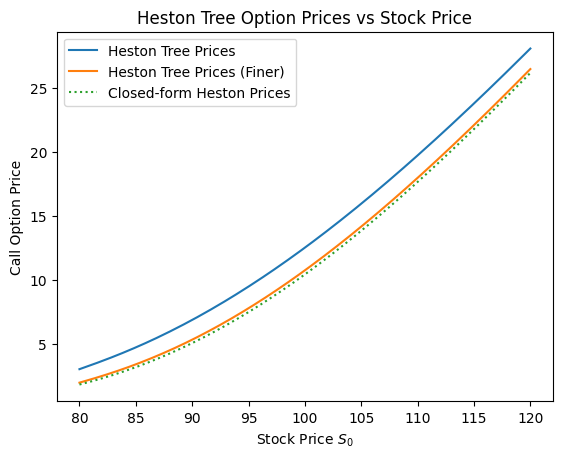

In [10]:
v0 = 0.04  # Fix initial variance
S = np.linspace(80, 120, 200)
k = 0
prices = [heston_tree_bs.price(v0, S0, k) for S0 in S]
prices_finer = [heston_tree_bs_finer.price(v0, S0, k) for S0 in S]
closed_prices = [heston_call_price(S0, K, T, r, kappa+1e-6, theta, sigma+1e-6, rho, v0) for S0 in S]
bs_prices = [black_scholes(S0, K, r, np.sqrt(v0), T, 'call') for S0 in S]
plt.plot(S, prices, label='Heston Tree Prices')
plt.plot(S, prices_finer, label='Heston Tree Prices (Finer)')
plt.plot(S, closed_prices, label='Closed-form Heston Prices', linestyle=':')
# plt.plot(S, bs_prices, label='Black-Scholes Prices', linestyle='--')
plt.title('Heston Tree Option Prices vs Stock Price')
plt.xlabel('Stock Price $S_0$')
plt.ylabel('Call Option Price')
plt.legend()
plt.show()